In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import CountVectorizer



In [2]:
df = pd.read_csv("Airbnb_Data.csv")
pd.set_option('display.max_columns', None)  # want to see all columns
df

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,2015-04-19,f,NaN,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",2015-05-12,t,t,100%,2015-03-01,t,2017-01-22,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,14549287,4.605170,Apartment,Private room,{},1,1.0,Real Bed,flexible,False,NYC,one room in bushwick apt,NaN,t,t,NaN,2013-03-24,f,NaN,40.709025,-73.939405,one room bushwick,Williamsburg,0,NaN,https://a0.muscache.com/im/pictures/55162426/6...,11206.0,1.0,1.0
74107,13281809,5.043425,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,2.0,Real Bed,moderate,True,LA,"Located on the Pacific Coast Highway, this apa...",2016-08-15,t,f,100%,2016-05-03,f,2017-04-15,33.871549,-118.396053,Spacious Hermosa 2 BR on PCH,Hermosa Beach,16,93.0,https://a0.muscache.com/im/pictures/2b86560b-a...,90254,2.0,4.0
74108,18688039,5.220356,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",5,1.0,Real Bed,moderate,True,NYC,A modern apartment located in East Williamsbur...,2015-01-03,t,t,100%,2012-01-05,t,2017-09-10,40.706749,-73.942377,Modern 2 Bedroom Apartment in Williamsburg,Williamsburg,43,94.0,https://a0.muscache.com/im/pictures/7fbe448c-5...,11206.0,2.0,2.0
74109,17045948,5.273000,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.0,Real Bed,strict,True,NYC,"Fully renovated, designer's studio located in ...",NaN,t,f,100%,2017-09-17,t,NaN,40.738535,-74.000157,Designer's Apartment in HEART of NYC,West Village,0,NaN,https://a0.muscache.com/im/pictures/b3971b63-0...,10011,0.0,2.0


In [3]:
df.dtypes

id                          int64
log_price                 float64
property_type              object
room_type                  object
amenities                  object
accommodates                int64
bathrooms                 float64
bed_type                   object
cancellation_policy        object
cleaning_fee                 bool
city                       object
description                object
first_review               object
host_has_profile_pic       object
host_identity_verified     object
host_response_rate         object
host_since                 object
instant_bookable           object
last_review                object
latitude                  float64
longitude                 float64
name                       object
neighbourhood              object
number_of_reviews           int64
review_scores_rating      float64
thumbnail_url              object
zipcode                    object
bedrooms                  float64
beds                      float64
dtype: object

# 1. Data Understanding & Background

In [4]:
# check NaN CHECK.
nan_counts = df.isnull().sum().to_frame('nan_count')
total_rows = df.shape[0]

#  NAN Ratio.
nan_counts['nan_percentage'] = (nan_counts['nan_count'] / total_rows) * 100
nan_counts

,nan_count,nan_percentage
id,0,0.000000
log_price,0,0.000000
property_type,0,0.000000
room_type,0,0.000000
amenities,0,0.000000
accommodates,0,0.000000
bathrooms,200,0.269865
bed_type,0,0.000000
cancellation_policy,0,0.000000
cleaning_fee,0,0.000000


Several columns appear to require processing. The 'amenities' and 'description' fields, being text but formatted as dictionaries, seem to need special handling. There are also more null values than expected, which necessitates careful selection of columns for use in prediction. I plan to conduct a brief exploratory data analysis (EDA) and some basic visualizations before moving on. Furthermore, I want to use the 'LOG_PRICE' to identify which factors most significantly impact the price, and later, I hope to predict prices using a variety of columns.


# 2. Data Cleaning & Preprocessing

In [5]:

#Convert log price to actual price
#df['price'] = np.exp(df['log_price'])
#df = df.drop('log_price', axis=1)


# Replace missing values in numerical columns with the median value
for column in ['bathrooms', 'bedrooms', 'beds']:
    mean_value = df[column].median()
    df[column].fillna(mean_value, inplace=True)
    # Create a new column to indicate the presence of missing values in the original column
    df[column + '_missing'] = df[column].isnull().astype(int)

    
# Drop columns that are not necessary or have a high percentage of missing values
drop_columns = ['id', 'zipcode', 'thumbnail_url', 'last_review', 'first_review', 'host_response_rate', 'host_since', 'host_has_profile_pic', 'neighbourhood', 'bathrooms_missing', 'bedrooms_missing', 'beds_missing']
df.drop(drop_columns, axis=1, inplace=True)


# Handle missing values in 'review_scores_rating'
# If the number of reviews is zero, replace missing values with the mean score of such listings
mean_rating_when_no_reviews = df[df['number_of_reviews'] == 0]['review_scores_rating'].mean()
df.loc[df['number_of_reviews'] == 0, 'review_scores_rating'].fillna(mean_rating_when_no_reviews, inplace=True)


# For remaining missing values in 'review_scores_rating', fill with the overall mean of the column
mean_rating = df['review_scores_rating'].mean()
df['review_scores_rating'].fillna(mean_rating, inplace=True)


# Fill missing values in'host_identity_verified' with 'f'
df['host_identity_verified'].fillna('f', inplace=True)

df

,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,host_identity_verified,instant_bookable,latitude,longitude,name,number_of_reviews,review_scores_rating,bedrooms,beds
0,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",t,f,40.696524,-73.991617,Beautiful brownstone 1-bedroom,2,100.000000,1.0,1.0
1,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,f,t,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,6,93.000000,3.0,3.0
2,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,t,t,40.808110,-73.943756,The Garden Oasis,10,92.000000,1.0,3.0
3,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,t,f,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,0,94.067365,2.0,2.0
4,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",t,t,38.925627,-77.034596,Great studio in midtown DC,4,40.000000,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,4.605170,Apartment,Private room,{},1,1.0,Real Bed,flexible,False,NYC,one room in bushwick apt,t,f,40.709025,-73.939405,one room bushwick,0,94.067365,1.0,1.0
74107,5.043425,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,2.0,Real Bed,moderate,True,LA,"Located on the Pacific Coast Highway, this apa...",f,f,33.871549,-118.396053,Spacious Hermosa 2 BR on PCH,16,93.000000,2.0,4.0
74108,5.220356,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",5,1.0,Real Bed,moderate,True,NYC,A modern apartment located in East Williamsbur...,t,t,40.706749,-73.942377,Modern 2 Bedroom Apartment in Williamsburg,43,94.000000,2.0,2.0
74109,5.273000,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.0,Real Bed,strict,True,NYC,"Fully renovated, designer's studio located in ...",f,t,40.738535,-74.000157,Designer's Apartment in HEART of NYC,0,94.067365,0.0,2.0


In [6]:
#checking how many null values are left


df.isnull().sum()

log_price                 0
property_type             0
room_type                 0
amenities                 0
accommodates              0
bathrooms                 0
bed_type                  0
cancellation_policy       0
cleaning_fee              0
city                      0
description               0
host_identity_verified    0
instant_bookable          0
latitude                  0
longitude                 0
name                      0
number_of_reviews         0
review_scores_rating      0
bedrooms                  0
beds                      0
dtype: int64

# 3. Exploratory Data Analysis, EDA

# EDA#1 Word Cloud to analyse the description and identify the amenties.

In [7]:
vectorizer = CountVectorizer(stop_words='english', max_features=100) # erase words like (the, which, on ....)

X = vectorizer.fit_transform(df['description'])
words_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
word_counts = words_df.sum(axis=0).sort_values(ascending=False)

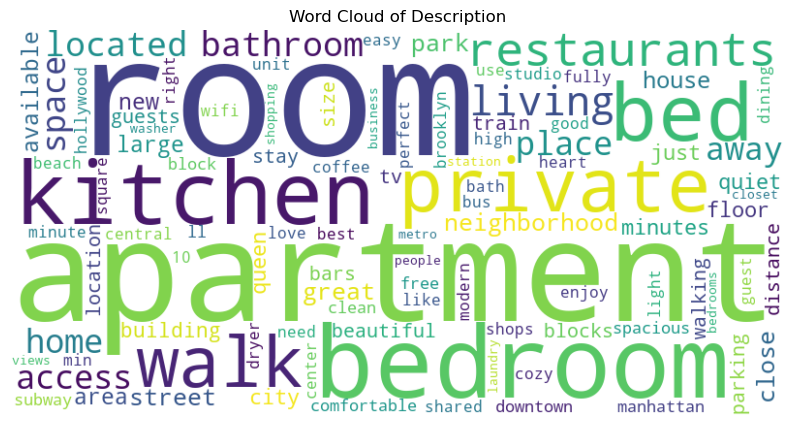

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=100)

# Generate word cloud
wordcloud.generate_from_frequencies(word_counts)

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Description')
plt.show()


From this word cloud we can undersatand that there are a lot of properties qwhich are appartments and have kitchen available, and restraunts in the neighbourhood. There are a lot of amenities that have been listed in the description which can be identified if we look carefully.  This is what we get in the first look but we will dive deep into it further in or analysis. 

# EDA#2 Top Amenities 

In [9]:
# amenities to list
def parse_amenities(amenities_str):
    # erase {}, '' , ""
    try:
        amenities_str = amenities_str.strip('{}').replace('"', '')
        amenities_list = amenities_str.split(',')
        return [amenity.strip() for amenity in amenities_list]
    except Exception as e:
        print(f"Error parsing amenities: {e}")
        return []

df['amenities'] = df['amenities'].apply(parse_amenities)

# gethering
all_amenities = [amenity for sublist in df['amenities'] for amenity in sublist]

# frequnecy
amenity_counts = Counter(all_amenities)

# top 15
print(amenity_counts.most_common(15))

[('Wireless Internet', 71265), ('Kitchen', 67526), ('Heating', 67073), ('Essentials', 64005), ('Smoke detector', 61727), ('Air conditioning', 55210), ('TV', 52458), ('Shampoo', 49465), ('Hangers', 49173), ('Carbon monoxide detector', 47190), ('Internet', 44648), ('Laptop friendly workspace', 43703), ('Hair dryer', 43330), ('Washer', 43169), ('Dryer', 42711)]


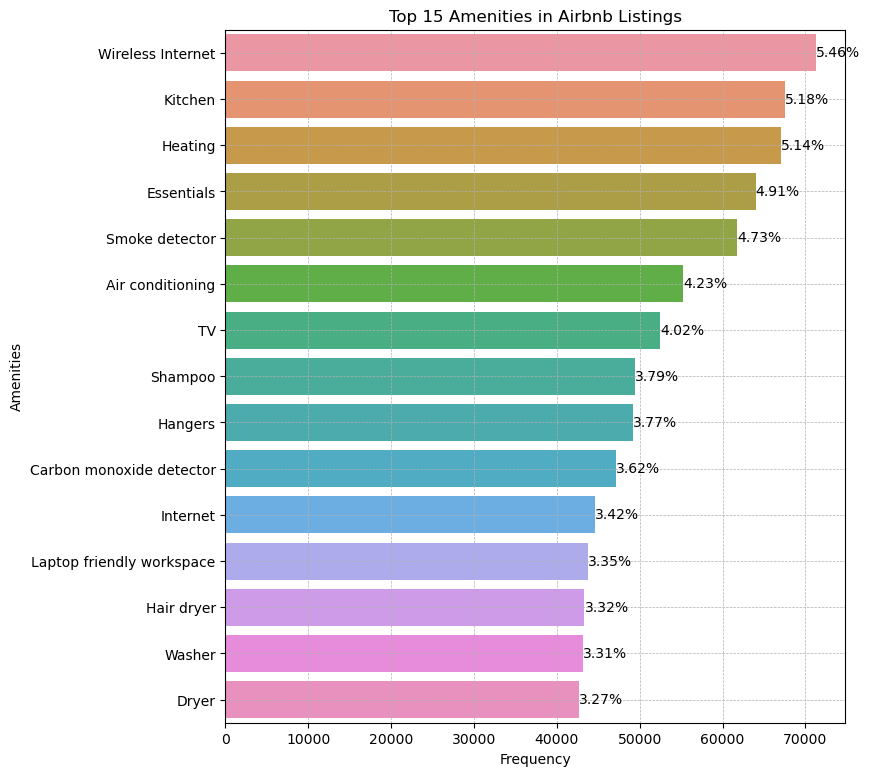

In [10]:
# visualization
def top_amenities(amenity_counts, n):
    amenities_df = pd.DataFrame(list(amenity_counts.items()), columns=['Amenity', 'Count'])
    total_count_all_amenities = amenities_df['Count'].sum()
    top_amenities_df = amenities_df.sort_values(by='Count', ascending=False).head(n)
    top_amenities_df['Percentage'] = (top_amenities_df['Count'] / total_count_all_amenities) * 100

    plt.figure(figsize=(8, 0.6 * n))
    ax = sns.barplot(x='Count', y='Amenity', data=top_amenities_df)

    for p in ax.patches:
        width = p.get_width()
        plt.text(width + 3,
                 p.get_y() + p.get_height() / 2,
                 '{:1.2f}%'.format(p.get_width() / total_count_all_amenities * 100),  # 텍스트
                 va = 'center')

    plt.title(f'Top {n} Amenities in Airbnb Listings')
    plt.xlabel('Frequency')
    plt.ylabel('Amenities')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

top_amenities(amenity_counts, 15)

# NLP ANALYSIS

In [11]:
print(df['description'].loc[df.index[1]])

Enjoy travelling during your stay in Manhattan. My place is centrally located near Times Square and Central Park with easy access to main subways as well as walking distance to many popular restaurants and bus tours. My place is close to the subway, Totto Ramen, Hell's Kitchen, Ippudo Westside, Empanada Mama, Intrepid Sea, Air & Space Museum. My place has three true bedrooms and one bathroom. The kitchen is stocked with stainless steel appliances like the Keurig machine. The living room is spacious and can accommodate another person thanks to the pull out bed. My place is centrally located to some of the top attractions in the city. Feel free to explore the entire apartment and do not worry about sharing the space with any strangers. This is all yours during your stay. I am available via text/email/phone for anything you might need. - Times Square - Rockefeller Plaza - Central Park  - 5th Avenue Shopping  -Broadway Theater District  - Empire State Building  - Hudson River Express Subwa

(-0.5, 399.5, 199.5, -0.5)

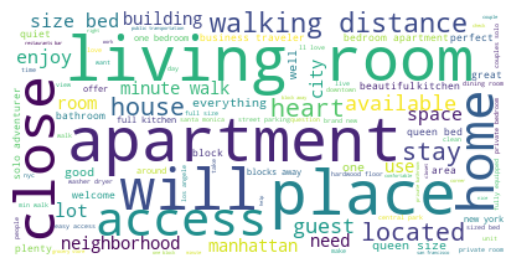

In [12]:
#word cloud fpor all descriptions 
## let's draw a wordcloud of all text
text = ' '.join(df['description'].astype(str)).lower()

from wordcloud import WordCloud
wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

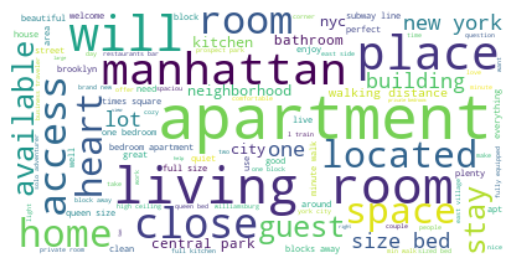

In [13]:
# Filter the DataFrame to include only descriptions where the city is "NYC"
nyc_descriptions = df[df['city'] == 'NYC']['description'].astype(str).str.lower()

# Join the filtered descriptions into a single text string
text_nyc = ' '.join(nyc_descriptions)

# Generate the word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud_nyc = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text_nyc)
plt.figure()
plt.imshow(wordcloud_nyc, interpolation="bilinear")
plt.axis("off")
plt.show()


In [14]:
import spacy
from pprint import pp as pprint

## initialize the NLP engine to be english
nlp = spacy.load("en_core_web_sm")

In [15]:
text = df['description'][4]
pprint(text)

('Cool, cozy, and comfortable studio located in the heart of the city. '
 "Literally a 10 min walk to Columbia Heights metro where you'll find "
 'shopping, theater, bars and diverse restaurants. Fits two very well, and is '
 "very convenient to other great areas. Welcome home!  It's in a diverse "
 "building,  where you meet alot of international people. It's located around "
 'different embassies, whom may provide a tour.  Theres tons of people from '
 'over the world! Tons of different restaurants,  and cultural things to do. '
 'Less than a mile walk to Dupont Circle, U Street, Adams Morgan, Columbia '
 'Heights metro.  Tons of buses, and underground metro at your fingertips I '
 'can provide groceries for an affordable fee')


In [16]:
doc = nlp(text)
for token in doc[:70]:
    print(" --> ".join([token.text, token.pos_, token.tag_]))

Cool --> ADJ --> JJ
, --> PUNCT --> ,
cozy --> NOUN --> NN
, --> PUNCT --> ,
and --> CCONJ --> CC
comfortable --> ADJ --> JJ
studio --> NOUN --> NN
located --> VERB --> VBN
in --> ADP --> IN
the --> DET --> DT
heart --> NOUN --> NN
of --> ADP --> IN
the --> DET --> DT
city --> NOUN --> NN
. --> PUNCT --> .
Literally --> ADV --> RB
a --> DET --> DT
10 --> NUM --> CD
min --> NOUN --> NN
walk --> NOUN --> NN
to --> ADP --> IN
Columbia --> PROPN --> NNP
Heights --> PROPN --> NNPS
metro --> PROPN --> NNP
where --> SCONJ --> WRB
you --> PRON --> PRP
'll --> AUX --> MD
find --> VERB --> VB
shopping --> NOUN --> NN
, --> PUNCT --> ,
theater --> NOUN --> NN
, --> PUNCT --> ,
bars --> NOUN --> NNS
and --> CCONJ --> CC
diverse --> ADJ --> JJ
restaurants --> NOUN --> NNS
. --> PUNCT --> .
Fits --> VERB --> VBZ
two --> NUM --> CD
very --> ADV --> RB
well --> ADV --> RB
, --> PUNCT --> ,
and --> CCONJ --> CC
is --> AUX --> VBZ
very --> ADV --> RB
convenient --> ADJ --> JJ
to --> ADP --> IN
other -->

In [17]:
def extract_tips(nlp, review_text):
    # Process the review text
    doc = nlp(review_text)
    # Define the POS tagging patterns for tips
    tip_patterns = [
        [{"POS": "ADJ"}, {"POS": "NOUN"}],  # e.g., narrow seats
        [{"POS": "ADJ"}, {"POS": "NOUN"}, {"POS": "NOUN"}], # poor leg room
        [{"POS": "VERB"}, {"POS": "ADJ"}, {"POS": "NOUN"}], # try delicious food
        [{"POS": "VERB"}, {"POS": "NOUN"}, {"POS": "ADJ"}], # Visit museum stunning
        [{"POS": "ADV"}, {"POS": "VERB"}, {"POS": "NOUN"}], # Quickly grab tickets
        [{"POS": "NOUN"}, {"POS": "ADP"}, {"POS": "NOUN"}], # Plenty of parking
        [{"POS": "VERB"}, {"POS": "NOUN"}, {"POS": "NOUN"}], # Bring sunscreen hat
        [{"POS": "ADJ"}, {"POS": "NOUN"}, {"POS": "ADP"}, {"POS": "NOUN"}] # Great place for kids
        ## Add more if you find good patterns
    ]

    # Extract tips based on the defined patterns
    tips = []
    matcher = spacy.matcher.Matcher(nlp.vocab)
    for i, pattern in enumerate(tip_patterns):
        matcher.add(f"TIP_PATTERN_{i}", [pattern])

    for sent in doc.sents:
        matches = matcher(sent)
        for match_id, start, end in matches:
            tip = sent[start:end].text
            tips.append(tip)

    return tips

In [18]:
text = df['description'][4]
pprint(text)

('Cool, cozy, and comfortable studio located in the heart of the city. '
 "Literally a 10 min walk to Columbia Heights metro where you'll find "
 'shopping, theater, bars and diverse restaurants. Fits two very well, and is '
 "very convenient to other great areas. Welcome home!  It's in a diverse "
 "building,  where you meet alot of international people. It's located around "
 'different embassies, whom may provide a tour.  Theres tons of people from '
 'over the world! Tons of different restaurants,  and cultural things to do. '
 'Less than a mile walk to Dupont Circle, U Street, Adams Morgan, Columbia '
 'Heights metro.  Tons of buses, and underground metro at your fingertips I '
 'can provide groceries for an affordable fee')


In [19]:
## test the function
extract_tips(nlp, text)

['comfortable studio',
 'diverse restaurants',
 'great areas',
 'diverse building',
 'international people',
 'different embassies',
 'tons of people',
 'different restaurants',
 'cultural things',
 'Tons of buses',
 'underground metro',
 'affordable fee']

In [20]:
## split into NYC and SF
## Since it takes a long time to process all reviews, we will test with 100 instances
nyc = df['description'][df['city'] == "NYC"][:100]
sf = df['description'][df['city'] == "SF"][:100]
bos = df['description'][df['city'] == "Boston"][:100]
la = df['description'][df['city'] == "LA"][:100]

## tip extraction
tips_nyc = [extract_tips(nlp, c) for c in nyc]
tips_sf = [extract_tips(nlp, c) for c in sf]
tips_bos = [extract_tips(nlp, c) for c in bos]
tips_la = [extract_tips(nlp, c) for c in la]

## flattern the nested list
tips_nyc = [item for sublist in tips_nyc for item in sublist]
tips_sf = [item for sublist in tips_sf for item in sublist]
tips_bos = [item for sublist in tips_bos for item in sublist]
tips_la = [item for sublist in tips_la for item in sublist]

## count frequency
tips_nyc = pd.Series(tips_nyc).value_counts()
tips_sf = pd.Series(tips_sf).value_counts()
tips_bos = pd.Series(tips_bos).value_counts()
tips_la = pd.Series(tips_la).value_counts()

print(tips_nyc[:5])
print(tips_sf[:5])
print(tips_bos[:5])
print(tips_la[:5])

few blocks          10
private room         9
floor to ceiling     6
full kitchen         6
common area          6
dtype: int64
private entrance         9
Victorian home           8
public transportation    8
central location         7
solo adventurers         7
dtype: int64
first floor              16
third floor              12
public transportation    10
solo adventurers          9
easy access               7
dtype: int64
private bathroom    11
solo adventurers    10
own bathroom         7
full kitchen         7
easy access          6
dtype: int64


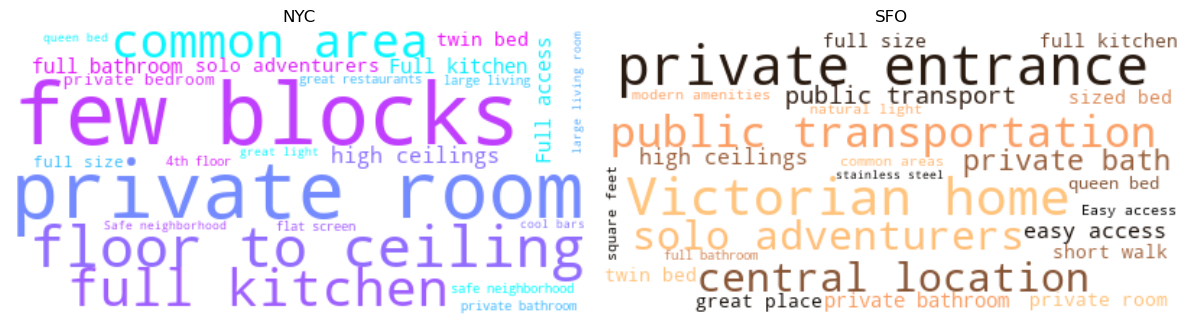

In [21]:
## generating two word cloud
# Create a single figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

wordcloud1 = WordCloud(background_color='white', colormap='cool', min_font_size=8).generate_from_frequencies(tips_nyc)
ax1.imshow(wordcloud1, interpolation='bilinear')
ax1.axis('off')
ax1.set_title('NYC')

wordcloud2 = WordCloud(background_color='white', colormap='copper', min_font_size=8).generate_from_frequencies(tips_sf)
ax2.imshow(wordcloud2, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('SFO')




# Adjust the spacing between subplots
plt.tight_layout()

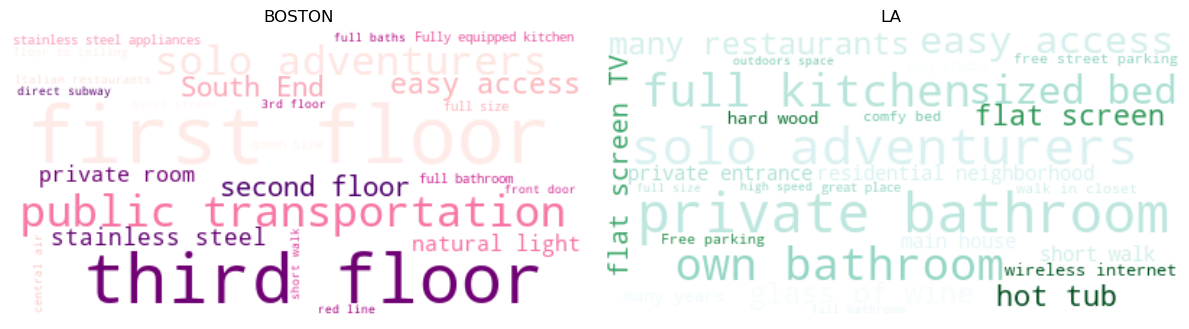

In [22]:
## generating two word cloud
# Create a single figure with two subplots
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 8))

wordcloud3 = WordCloud(background_color='white', colormap='RdPu', min_font_size=8).generate_from_frequencies(tips_bos)
ax3.imshow(wordcloud3, interpolation='bilinear')
ax3.axis('off')
ax3.set_title('BOSTON')

wordcloud4 = WordCloud(background_color='white', colormap='BuGn', min_font_size=8).generate_from_frequencies(tips_la)
ax4.imshow(wordcloud4, interpolation='bilinear')
ax4.axis('off')
ax4.set_title('LA')


# Adjust the spacing between subplots
plt.tight_layout()

# 4. Predictive Modeling or Algorithm Selection


We want to predict 'log_price' using several columns, especially by isolating 'amenities'. However, the creation of too many columns led to memory issues and caused crashes. Consequently, We've decided to focus on the top 15 most frequently occurring amenities for analysis. We plan to use XGBoost for this task.

* XGBoost

XGBoost (eXtreme Gradient Boosting) is an efficient and scalable implementation of gradient boosting framework. It is a powerful machine learning algorithm that has proven effective across a wide range of regression and classification problems. XGBoost is known for its performance and speed, particularly in structured or tabular data.


In [23]:
all_amenities = []
for amenities_list in df['amenities']:
    all_amenities.extend(amenities_list)

# frequency of amentity
amenity_counts = Counter(all_amenities)

# top 15
top_amenities = [amenity for amenity, count in amenity_counts.most_common(15)]

# make dummies
for amenity in top_amenities:
    df['amenity_' + amenity] = df['amenities'].apply(lambda x: 1 if amenity in x else 0)


df

,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,host_identity_verified,instant_bookable,latitude,longitude,name,number_of_reviews,review_scores_rating,bedrooms,beds,amenity_Wireless Internet,amenity_Kitchen,amenity_Heating,amenity_Essentials,amenity_Smoke detector,amenity_Air conditioning,amenity_TV,amenity_Shampoo,amenity_Hangers,amenity_Carbon monoxide detector,amenity_Internet,amenity_Laptop friendly workspace,amenity_Hair dryer,amenity_Washer,amenity_Dryer
0,5.010635,Apartment,Entire home/apt,"[Wireless Internet, Air conditioning, Kitchen,...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",t,f,40.696524,-73.991617,Beautiful brownstone 1-bedroom,2,100.000000,1.0,1.0,1,1,1,1,0,1,0,0,0,0,0,0,1,0,0
1,5.129899,Apartment,Entire home/apt,"[Wireless Internet, Air conditioning, Kitchen,...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,f,t,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,6,93.000000,3.0,3.0,1,1,1,1,1,1,0,1,1,0,0,0,1,1,1
2,4.976734,Apartment,Entire home/apt,"[TV, Cable TV, Wireless Internet, Air conditio...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,t,t,40.808110,-73.943756,The Garden Oasis,10,92.000000,1.0,3.0,1,1,1,1,1,1,1,1,1,1,0,1,1,0,0
3,6.620073,House,Entire home/apt,"[TV, Cable TV, Internet, Wireless Internet, Ki...",4,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,t,f,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,0,94.067365,2.0,2.0,1,1,1,1,1,0,1,0,0,1,1,0,0,1,1
4,4.744932,Apartment,Entire home/apt,"[TV, Internet, Wireless Internet, Air conditio...",2,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",t,t,38.925627,-77.034596,Great studio in midtown DC,4,40.000000,0.0,1.0,1,1,1,1,1,1,1,1,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,4.605170,Apartment,Private room,[],1,1.0,Real Bed,flexible,False,NYC,one room in bushwick apt,t,f,40.709025,-73.939405,one room bushwick,0,94.067365,1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
74107,5.043425,Apartment,Entire home/apt,"[TV, Cable TV, Internet, Wireless Internet, Ki...",4,2.0,Real Bed,moderate,True,LA,"Located on the Pacific Coast Highway, this apa...",f,f,33.871549,-118.396053,Spacious Hermosa 2 BR on PCH,16,93.000000,2.0,4.0,1,1,1,1,1,0,1,1,1,0,1,0,1,1,1
74108,5.220356,Apartment,Entire home/apt,"[TV, Internet, Wireless Internet, Air conditio...",5,1.0,Real Bed,moderate,True,NYC,A modern apartment located in East Williamsbur...,t,t,40.706749,-73.942377,Modern 2 Bedroom Apartment in Williamsburg,43,94.000000,2.0,2.0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
74109,5.273000,Apartment,Entire home/apt,"[TV, Wireless Internet, Air conditioning, Kitc...",2,1.0,Real Bed,strict,True,NYC,"Fully renovated, designer's studio located in ...",f,t,40.738535,-74.000157,Designer's Apartment in HEART of NYC,0,94.067365,0.0,2.0,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1


In [24]:
# I think these columns are not useful..
df.drop(['amenities','latitude','longitude','name' ], axis=1, inplace=True)


In [25]:
df_final = df
df_final = df_final.drop('city' , axis=1)
df_final = df_final.drop('description' , axis=1)
#df.drop('city' , axis=1)
df_final

,log_price,property_type,room_type,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,host_identity_verified,instant_bookable,number_of_reviews,review_scores_rating,bedrooms,beds,amenity_Wireless Internet,amenity_Kitchen,amenity_Heating,amenity_Essentials,amenity_Smoke detector,amenity_Air conditioning,amenity_TV,amenity_Shampoo,amenity_Hangers,amenity_Carbon monoxide detector,amenity_Internet,amenity_Laptop friendly workspace,amenity_Hair dryer,amenity_Washer,amenity_Dryer
0,5.010635,Apartment,Entire home/apt,3,1.0,Real Bed,strict,True,t,f,2,100.000000,1.0,1.0,1,1,1,1,0,1,0,0,0,0,0,0,1,0,0
1,5.129899,Apartment,Entire home/apt,7,1.0,Real Bed,strict,True,f,t,6,93.000000,3.0,3.0,1,1,1,1,1,1,0,1,1,0,0,0,1,1,1
2,4.976734,Apartment,Entire home/apt,5,1.0,Real Bed,moderate,True,t,t,10,92.000000,1.0,3.0,1,1,1,1,1,1,1,1,1,1,0,1,1,0,0
3,6.620073,House,Entire home/apt,4,1.0,Real Bed,flexible,True,t,f,0,94.067365,2.0,2.0,1,1,1,1,1,0,1,0,0,1,1,0,0,1,1
4,4.744932,Apartment,Entire home/apt,2,1.0,Real Bed,moderate,True,t,t,4,40.000000,0.0,1.0,1,1,1,1,1,1,1,1,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,4.605170,Apartment,Private room,1,1.0,Real Bed,flexible,False,t,f,0,94.067365,1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
74107,5.043425,Apartment,Entire home/apt,4,2.0,Real Bed,moderate,True,f,f,16,93.000000,2.0,4.0,1,1,1,1,1,0,1,1,1,0,1,0,1,1,1
74108,5.220356,Apartment,Entire home/apt,5,1.0,Real Bed,moderate,True,t,t,43,94.000000,2.0,2.0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
74109,5.273000,Apartment,Entire home/apt,2,1.0,Real Bed,strict,True,f,t,0,94.067365,0.0,2.0,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# dummies
df_final = pd.get_dummies(df_final, drop_first=True)

# split
X = df_final.drop('log_price', axis=1)
y = df_final['log_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# train
model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# feature importance
feature_importances = model.feature_importances_

# feature to dataframe
features = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# top 10 f
top_features = features.head(10)['Feature'].tolist()
X_train_reduced = X_train[top_features]
X_test_reduced = X_test[top_features]

In [28]:
top_features

['room_type_Private room',
 'bedrooms',
 'room_type_Shared room',
 'bathrooms',
 'accommodates',
 'number_of_reviews',
 'review_scores_rating',
 'amenity_TV',
 'property_type_House',
 'cleaning_fee']

In [29]:
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error

# XGBoost
xgb_model = XGBRegressor(n_estimators=50, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)



# compare
print(f"XGBoost MSE: {mse_xgb}")



XGBoost MSE: 0.21509327119540858


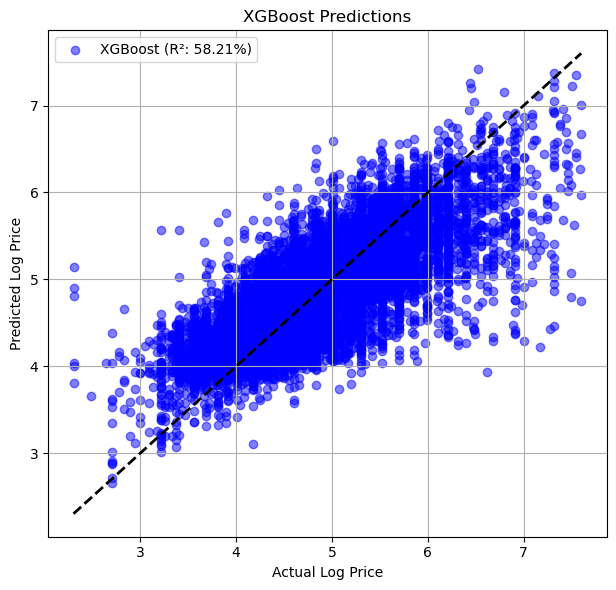

In [50]:
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

# XGBoost train
xgb_model = XGBRegressor(n_estimators=70, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
r_squared_xgb = r2_score(y_test, y_pred_xgb)
accuracy_percentage_xgb = r_squared_xgb * 100



plt.figure(figsize=(12, 6))

# XGBoost
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_xgb, color='blue', alpha=0.5, label=f'XGBoost (R²: {accuracy_percentage_xgb:.2f}%)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')
plt.title('XGBoost Predictions')
plt.grid(True)
plt.legend()



plt.tight_layout()
plt.show()


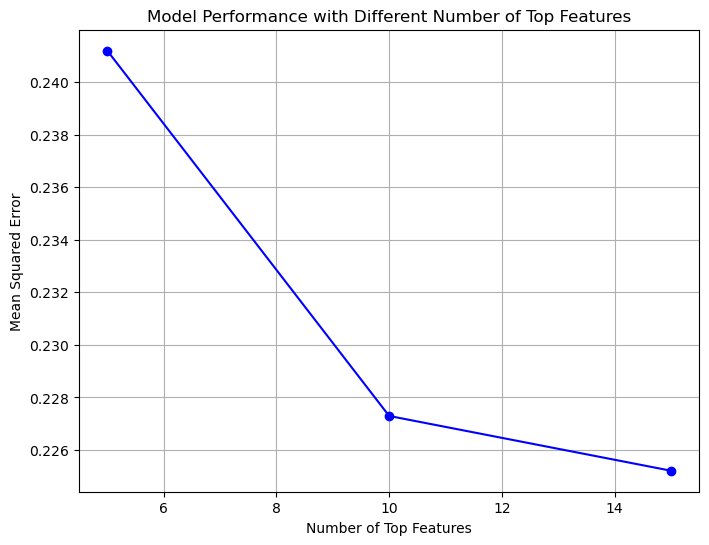

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# split
X = df_final.drop('log_price', axis=1)
y = df_final['log_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
model.fit(X_train, y_train)

feature_importances = model.feature_importances_
features = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# compare numbers of feature
top_features_counts = [5, 10, 15]
mse_results = []

for count in top_features_counts:
    top_features = features.head(count)['Feature'].tolist()
    X_train_reduced = X_train[top_features]
    X_test_reduced = X_test[top_features]

    # train
    model.fit(X_train_reduced, y_train)

    # predict
    y_pred = model.predict(X_test_reduced)

    # MSE
    mse = mean_squared_error(y_test, y_pred)
    mse_results.append(mse)

# visual
plt.figure(figsize=(8, 6))
plt.plot(top_features_counts, mse_results, marker='o', linestyle='-', color='b')
plt.title('Model Performance with Different Number of Top Features')
plt.xlabel('Number of Top Features')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()
